# install libraries

In [140]:
!pip install xgboost
!pip install wordcloud

# import

In [142]:
import re
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words
from nltk.stem import WordNetLemmatizer
# Ensure you have the necessary NLTK data files for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression ## Logistic Regression
from xgboost import XGBClassifier                     # XGBoost
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from wordcloud import WordCloud, STOPWORDS
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# load the files

In [144]:
df = pd.read_csv("C:/Users/DELL/nlp/SPOTIFY/Spotify User Reviews.csv")

# display the data

In [146]:
df

,Review,label
0,"Great music service, the audio is high quality...",POSITIVE
1,Please ignore previous negative rating. This a...,POSITIVE
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE
3,Really buggy and terrible to use as of recently,NEGATIVE
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE
...,...,...
52697,Yes the best,POSITIVE
52698,Spotify won my heart in Feb 2024 You won my he...,POSITIVE
52699,I tried to open the app and it wont open I res...,POSITIVE
52700,Good,POSITIVE


# info

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52702 entries, 0 to 52701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  52686 non-null  object
 1   label   52702 non-null  object
dtypes: object(2)
memory usage: 823.6+ KB


# describe

In [150]:
df.describe()

,Review,label
count,52686,52702
unique,51472,2
top,Good,NEGATIVE
freq,153,29423


In [151]:
df.shape

(52702, 2)

# sum of null values

In [153]:
df.isnull().sum()

Review    16
label      0
dtype: int64

# drop null values

In [155]:
df=df.dropna()

In [156]:
df.isnull().sum()

Review    0
label     0
dtype: int64

In [157]:
import re
import nltk
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words
from nltk.stem import WordNetLemmatizer

# sum of duplicate values

In [159]:
df.duplicated().sum()

1214

# unique values

In [161]:
for i, col in enumerate(df.columns):
  print(df.columns[i], '::\n', df[str(col)].unique(), '\n\n')

Review ::
 ['Great music service, the audio is high quality and the app is easy to use. Also very quick and friendly support.'
 'Please ignore previous negative rating. This app is super great. I give it five stars+'
 'This pop-up "Get the best Spotify experience on Android 12" is too annoying. Please let\'s get rid of this.'
 ...
 'Spotify won my heart in Feb 2024 You won my heart With music and lyrics and then language educational podcasts and audio books you finally won my heart over With just a free trial and I was convinced I found what I have been looking for all these while and finally settling down with this like marriage haha'
 'I tried to open the app and it wont open I restarted my phone but Ill tap the icon itll freeze and then send me to my home screen I uninstalled and reinstalled and that fixed it for a day but now its happening again I dont want to have to redownload everything again'
 'Nice app to play music and at very affordable price'] 


label ::
 ['POSITIVE' 'NEGA

# drop duplicates

In [163]:
df=df.drop_duplicates()

In [164]:
df.duplicated().sum()

0

# lemmatizer

In [166]:
lemmatizer = WordNetLemmatizer()

# cleaning the data

In [168]:
def clean_text(text):
    # Remove special characters and replace them with spaces
    text = re.sub(r'\W', ' ', text)

    # Convert all characters to lowercase
    text = text.lower()

    # Tokenize the text (split it into individual words)
    words = text.split()

    # Remove stop words and lemmatize each word
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # Join the cleaned words back into a single string
    return ' '.join(cleaned_words)

# cleaned data

In [170]:
df['cleaned_text'] = df['Review'].apply(clean_text)

In [171]:
df

,Review,label,cleaned_text
0,"Great music service, the audio is high quality...",POSITIVE,great music service audio high quality app eas...
1,Please ignore previous negative rating. This a...,POSITIVE,ignore previous negative rating app super grea...
2,"This pop-up ""Get the best Spotify experience o...",NEGATIVE,pop best spotify experience android 12 annoyin...
3,Really buggy and terrible to use as of recently,NEGATIVE,really buggy terrible use recently
4,Dear Spotify why do I get songs that I didn't ...,NEGATIVE,dear spotify song didn t playlist shuffle play
...,...,...,...
52696,Bass volume song quality is appreciative,POSITIVE,bass volume song quality appreciative
52697,Yes the best,POSITIVE,yes best
52698,Spotify won my heart in Feb 2024 You won my he...,POSITIVE,spotify won heart feb 2024 won heart music lyr...
52699,I tried to open the app and it wont open I res...,POSITIVE,tried open app wont open restarted phone ill t...


# visualization

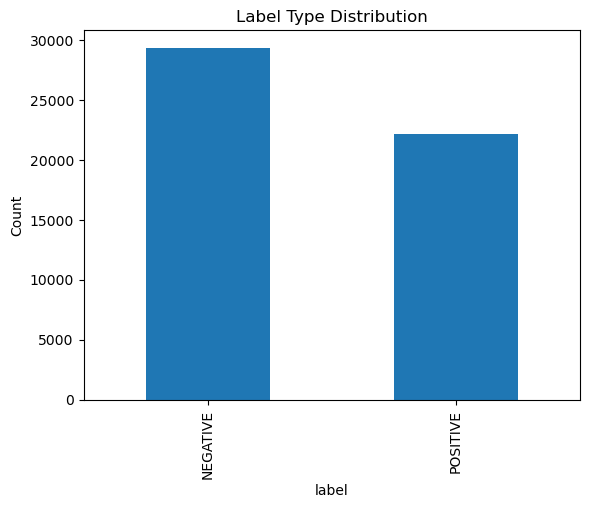

In [173]:
df['label'].value_counts().plot(kind='bar')
plt.title('Label Type Distribution')
plt.xlabel('label')
plt.ylabel('Count')
plt.show()

# Vectorization

In [175]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize a TF-IDF vectorizer with a maximum of 500 features (terms)
tfidf_vectorizer = TfidfVectorizer(max_features=500)

# Apply the TF-IDF vectorizer to the cleaned email text data and transform it into numerical features
inputs = tfidf_vectorizer.fit_transform(df['cleaned_text'])

In [176]:
inputs

<51472x500 sparse matrix of type '<class 'numpy.float64'>'
	with 478506 stored elements in Compressed Sparse Row format>

# mapping

In [178]:
inputs = inputs
outputs = df['label'].map({'NEGATIVE': 0, 'POSITIVE': 1})
outputs

0        1
1        1
2        0
3        0
4        0
        ..
52696    1
52697    1
52698    1
52699    1
52701    1
Name: label, Length: 51472, dtype: int64

# split the data

In [180]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size = 0.30, random_state = 42)

In [181]:
# Printing the shapes of the training and test datasets
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (36030, 500)
Shape of X_test: (15442, 500)
Shape of y_train: (36030,)
Shape of y_test: (15442,)


# models

#  LogisticRegression

In [184]:
from sklearn.linear_model import LogisticRegression ## Logistic Regression
clf_logreg = LogisticRegression()
clf_logreg.fit(X_train, y_train)
# Prediction using Logistic regression
y_pred_logreg = clf_logreg.predict(X_test)
# score
from sklearn.metrics import classification_report
clf_rpt_logreg = classification_report(y_test, y_pred_logreg)
print('classification report for logistic regression \n',clf_rpt_logreg )
# confusion matric
#from sklearn.metrics import confusion_matrix
#print('Confusion matrix for Logistic Regression \n', sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot = True))

classification report for logistic regression 
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      8838
           1       0.85      0.83      0.84      6604

    accuracy                           0.86     15442
   macro avg       0.86      0.86      0.86     15442
weighted avg       0.86      0.86      0.86     15442



#  RandomForestClassifier

In [186]:
from sklearn.ensemble import RandomForestClassifier
# Creating a Random Forest Classifier
rf_classifier = RandomForestClassifier()
# Fitting the classifier to the training data
rf_classifier.fit(X_train, y_train)
# Making predictions using the Random Forest classifier
y_pred_rf = rf_classifier.predict(X_test)
# Generating a classification report for the Random Forest classifier
from sklearn.metrics import classification_report
classification_report_rf = classification_report(y_test, y_pred_rf)
# Printing the classification report
print('Classification report for Random Forest Classifier:\n', classification_report_rf)

Classification report for Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87      8838
           1       0.84      0.80      0.82      6604

    accuracy                           0.85     15442
   macro avg       0.85      0.84      0.84     15442
weighted avg       0.85      0.85      0.85     15442



# KNeighborsClassifier

Classification report for K-Nearest Neighbors Classifier:
               precision    recall  f1-score   support

           0       0.84      0.40      0.54      8838
           1       0.53      0.90      0.67      6604

    accuracy                           0.61     15442
   macro avg       0.68      0.65      0.60     15442
weighted avg       0.71      0.61      0.59     15442

Confusion matrix for K-Nearest Neighbors Classifier 
 Axes(0.125,0.11;0.62x0.77)


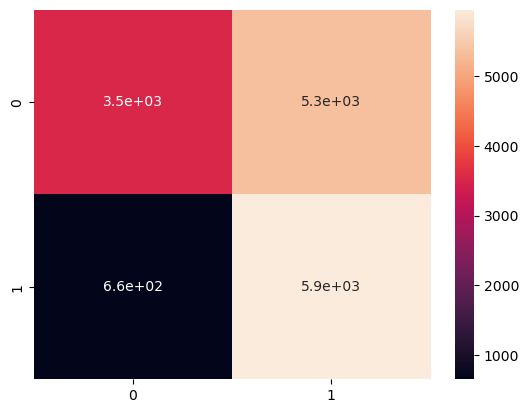

In [188]:
from sklearn.neighbors import KNeighborsClassifier
# Creating a K-Nearest Neighbors Classifier
knn_classifier = KNeighborsClassifier()
# Fitting the classifier to the training data
knn_classifier.fit(X_train, y_train)
# Making predictions using the K-Nearest Neighbors classifier
y_pred_knn = knn_classifier.predict(X_test)
# Generating a classification report for the K-Nearest Neighbors classifier
from sklearn.metrics import classification_report
classification_report_knn = classification_report(y_test, y_pred_knn)
# Printing the classification report
print('Classification report for K-Nearest Neighbors Classifier:\n', classification_report_knn)

# confusion matric
from sklearn.metrics import confusion_matrix
print('Confusion matrix for K-Nearest Neighbors Classifier \n', sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot = True))

# SVC

Classification report for Support Vector Classifier:
               precision    recall  f1-score   support

           0       0.88      0.89      0.88      8838
           1       0.85      0.83      0.84      6604

    accuracy                           0.87     15442
   macro avg       0.86      0.86      0.86     15442
weighted avg       0.87      0.87      0.87     15442

Confusion matrix for Support Vector Classifier 
 Axes(0.125,0.11;0.62x0.77)


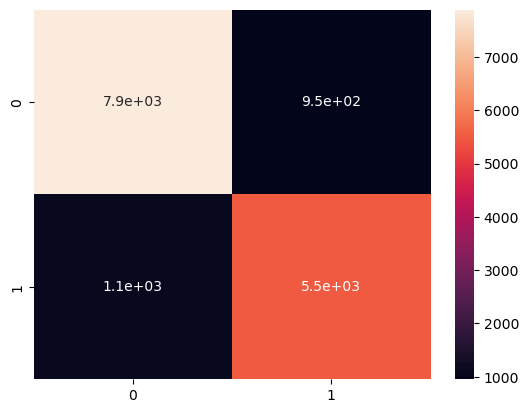

In [190]:
from sklearn.svm import SVC
# Creating a Support Vector Classifier
svc_classifier = SVC()
# Fitting the classifier to the training data
svc_classifier.fit(X_train, y_train)
# Making predictions using the Support Vector Classifier
y_pred_svc = svc_classifier.predict(X_test)
# Generating a classification report for the Support Vector Classifier
from sklearn.metrics import classification_report
classification_report_svc = classification_report(y_test, y_pred_svc)
# Printing the classification report
print('Classification report for Support Vector Classifier:\n', classification_report_svc)

# confusion matric
from sklearn.metrics import confusion_matrix
print('Confusion matrix for Support Vector Classifier \n', sns.heatmap(confusion_matrix(y_test, y_pred_svc), annot = True))

# DecisionTreeClassifier

In [192]:
from sklearn.tree import DecisionTreeClassifier
# Creating a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()
# Fitting the classifier to the training data
dt_classifier.fit(X_train, y_train)
# Making predictions using the Decision Tree Classifier
y_pred_dt = dt_classifier.predict(X_test)
# Generating a classification report for the Decision Tree Classifier
from sklearn.metrics import classification_report
classification_report_dt = classification_report(y_test, y_pred_dt)
# Printing the classification report
print('Classification report for Decision Tree Classifier:\n', classification_report_dt)

Classification report for Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81      8838
           1       0.75      0.75      0.75      6604

    accuracy                           0.79     15442
   macro avg       0.78      0.78      0.78     15442
weighted avg       0.79      0.79      0.79     15442

